In [186]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt 
import plotly_express as px 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [187]:
data = yf.download("AAPL", start='2020-01-01', end='2026-04-17')

[*********************100%***********************]  1 of 1 completed


In [188]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696655,72.455974,71.472477,71.629160,146322800
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [189]:
data.columns = data.columns.droplevel(1)

In [190]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1580 entries, 2020-01-02 to 2026-04-16
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1580 non-null   float64
 1   High    1580 non-null   float64
 2   Low     1580 non-null   float64
 3   Open    1580 non-null   float64
 4   Volume  1580 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.1 KB


In [191]:
# Calculating Price Change
data['Price_Change'] = data['Close'].diff()
data['pct_change'] = data['Close'].pct_change() * 100
data.fillna(0,inplace=True)
data.head(5)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change
Date,,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,0.000000,0.000000
2020-01-03,71.696655,72.455974,71.472477,71.629160,146322800,-0.703865,-0.972182
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200,0.571259,0.796772
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,-0.339844,-0.470255
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200,1.157043,1.608612


In [192]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Price_Change', 'pct_change'], dtype='object', name='Price')

In [193]:
# Seprating Gain and loss
data["Gain"] = data["Price_Change"].clip(lower=0)
data["Loss"] = -data["Price_Change"].clip(upper=0)

In [194]:
# Rolling Average
data['Avg_Gain'] = data['Gain'].rolling(5).mean()
data['Avg_Loss'] = data['Loss'].rolling(5).mean()

In [195]:
# Moving Average
data['MA_10'] = data['Close'].rolling(10).mean()
data['MA_50'] = data['Close'].rolling(50).mean()

# Volatility
data['Volatility'] = data['Close'].rolling(10).std()

In [196]:
data['Momentum'] = data['Close'] - data['Close'].shift(5)
data['EMA_10'] = data['Close'].ewm(span=10).mean()

In [197]:
ema12 = data['Close'].ewm(span=12).mean()
ema26 = data['Close'].ewm(span=26).mean()
data['MACD'] = ema12 - ema26

In [198]:
data['Volume_Change'] = data['Volume'].pct_change()

In [199]:
# Relative Strength
data['RS'] = data['Avg_Gain'] / data['Avg_Loss']

In [200]:
# RSI 
data['RSI'] = 100 - (100/(1 + data['RS']))

In [201]:
# Signal
data["Signal"] = "HOLD"
data.loc[(data["RSI"] < 30) & (data["RSI"].shift(1) >= 30), "Signal"] = "BUY"
data.loc[(data["RSI"] > 70) & (data["RSI"].shift(1) <= 70), "Signal"] = "SELL"

In [202]:
data.dropna(inplace=True)

In [203]:
data.head(21)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,...,MA_10,MA_50,Volatility,Momentum,EMA_10,MACD,Volume_Change,RS,RSI,Signal
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,67.164749,67.635923,61.119268,64.004286,370732000,7.185951,11.980819,7.185951,-0.000000,2.363586,...,68.282516,73.801323,3.939965,-2.672386,67.454021,-2.608121,-0.114086,0.815574,44.921011,HOLD
2020-03-16,58.524212,62.600436,57.990217,58.461387,322423600,-8.640537,-12.864691,0.000000,8.640537,2.363586,...,66.914915,73.523797,4.724435,-5.789356,65.830361,-3.153808,-0.130305,0.671195,40.162595,HOLD
2020-03-17,61.097530,62.245250,57.603618,59.804830,324056000,2.573318,4.397015,2.573318,-0.000000,1.951854,...,66.033945,73.311814,4.921715,-7.848019,64.969821,-3.343387,0.005063,0.554274,35.661298,HOLD
2020-03-18,59.601860,60.406475,57.294332,57.934643,300233600,-1.495670,-2.448005,0.000000,1.495670,1.951854,...,64.679147,73.058493,4.599403,-6.949158,63.993804,-3.571121,-0.073513,0.584093,36.872379,HOLD
2020-03-19,59.145191,61.092695,58.620863,59.775835,271857200,-0.456669,-0.766199,0.000000,0.456669,1.951854,...,63.515961,72.802836,4.349978,-0.833607,63.112221,-3.744613,-0.094514,0.921305,47.952042,HOLD
2020-03-20,55.390324,60.848652,55.090706,59.725089,401693200,-3.754868,-6.348559,0.000000,3.754868,0.514664,...,62.071280,72.448940,4.415861,-11.774426,61.708217,-4.133243,0.477589,0.179354,15.207783,BUY
2020-03-23,54.213604,55.211520,51.372085,55.110038,336752800,-1.176720,-2.124414,0.000000,1.176720,0.514664,...,61.061283,72.040462,4.966698,-4.310608,60.345542,-4.483168,-0.161667,0.373816,27.210023,HOLD
2020-03-24,59.652615,59.848331,56.612960,57.110709,287531200,5.439011,10.032557,5.439011,-0.000000,1.087802,...,60.131990,71.737390,4.125794,-1.444916,60.219554,-4.277227,-0.146165,0.790103,44.137291,HOLD
2020-03-25,59.323997,62.399894,59.029214,60.587700,303602000,-0.328617,-0.550885,0.000000,0.328617,1.087802,...,59.409288,71.395782,3.454877,-0.277863,60.056724,-4.093009,0.055892,0.951396,48.754637,HOLD


In [204]:
data.isnull().sum()

Price
Close            0
High             0
Low              0
Open             0
Volume           0
Price_Change     0
pct_change       0
Gain             0
Loss             0
Avg_Gain         0
Avg_Loss         0
MA_10            0
MA_50            0
Volatility       0
Momentum         0
EMA_10           0
MACD             0
Volume_Change    0
RS               0
RSI              0
Signal           0
dtype: int64

In [205]:
# data['Target'] = np.where(data['Close'].shift(-3) > data['Close'], "BUY", "SELL")

In [206]:
data['Future_Return'] = (data['Close'].shift(-3) - data['Close']) / data['Close']

data['Target'] = np.where(data['Future_Return'] > 0.02, "BUY",
                  np.where(data['Future_Return'] < -0.02, "SELL", "HOLD"))

In [207]:
le = LabelEncoder()
Y = le.fit_transform(data["Target"])

In [208]:
features = ["RSI", "Avg_Gain", "Avg_Loss", "Price_Change", "pct_change","Volatility","MA_10","MA_50","Volume_Change"]

X = data[features]
Y = data["Target"]

In [209]:
# Train test Split 
split = int(len(data)*0.8)

X_train = X[:split]
X_test = X[split:]

Y_train = Y[:split]
Y_test = Y[split:]

In [210]:

train_index = X_train.index
test_index = X_test.index

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = pd.DataFrame(X_train, index=train_index, columns=features)
X_test = pd.DataFrame(X_test, index=test_index, columns=features)

In [211]:
# LogisticRegression 
model_lr = LogisticRegression()
model_lr.fit(X_train,Y_train)

# Prediction
y_pred_lr = model_lr.predict(X_test)

# Accuracy Check
print('Accuracy :', accuracy_score(Y_test,y_pred_lr))
print('classification_report:',classification_report)

result = pd.DataFrame({
    'Actual': Y_test,
    'Prediction': y_pred_lr
})
result.head()

Accuracy : 0.5407166123778502
classification_report: <function classification_report at 0x000002592706EF20>


,Actual,Prediction
Date,,
2025-01-27,BUY,HOLD
2025-01-28,HOLD,HOLD
2025-01-29,SELL,HOLD
2025-01-30,SELL,HOLD
2025-01-31,HOLD,HOLD


In [212]:
# RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train,Y_train)

#Prediction
y_pred_rf = model_rf.predict(X_test)

#Accuracy check
print('accuracy_score :', accuracy_score(Y_test,y_pred_rf))
print('classification_report:',classification_report)


#Prediction check
result_rf = pd.DataFrame({
    'Actual':Y_test,
    'Predicted':y_pred_rf
})
result_rf.head()

accuracy_score : 0.3973941368078176
classification_report: <function classification_report at 0x000002592706EF20>


,Actual,Predicted
Date,,
2025-01-27,BUY,BUY
2025-01-28,HOLD,SELL
2025-01-29,SELL,HOLD
2025-01-30,SELL,HOLD
2025-01-31,HOLD,HOLD


In [213]:
# XGBClassifier
le = LabelEncoder()
Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)

model_XG = XGBClassifier()
model_XG.fit(X_train,Y_train)

y_pred_xg = model_XG.predict(X_test)

print('Accuracy :',accuracy_score(Y_test,y_pred_xg))
print('classification_report:',classification_report)


result_xg = pd.DataFrame({
    'Actual':Y_test,
    'Prediction':y_pred_xg
})
result_xg.head()


Accuracy : 0.39087947882736157
classification_report: <function classification_report at 0x000002592706EF20>


,Actual,Prediction
0,0,2
1,1,1
2,2,1
3,2,1
4,1,0


In [214]:
print("Train:", model_XG.score(X_train, Y_train))
print("Test:", model_XG.score(X_test, Y_test))

Train: 1.0
Test: 0.39087947882736157


In [215]:
data.head()

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,...,Volatility,Momentum,EMA_10,MACD,Volume_Change,RS,RSI,Signal,Future_Return,Target
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,67.164749,67.635923,61.119268,64.004286,370732000,7.185951,11.980819,7.185951,-0.000000,2.363586,...,3.939965,-2.672386,67.454021,-2.608121,-0.114086,0.815574,44.921011,HOLD,-0.112602,SELL
2020-03-16,58.524212,62.600436,57.990217,58.461387,322423600,-8.640537,-12.864691,0.000000,8.640537,2.363586,...,4.724435,-5.789356,65.830361,-3.153808,-0.130305,0.671195,40.162595,HOLD,0.010611,HOLD
2020-03-17,61.097530,62.245250,57.603618,59.804830,324056000,2.573318,4.397015,2.573318,-0.000000,1.951854,...,4.921715,-7.848019,64.969821,-3.343387,0.005063,0.554274,35.661298,HOLD,-0.093411,SELL
2020-03-18,59.601860,60.406475,57.294332,57.934643,300233600,-1.495670,-2.448005,0.000000,1.495670,1.951854,...,4.599403,-6.949158,63.993804,-3.571121,-0.073513,0.584093,36.872379,HOLD,-0.090404,SELL
2020-03-19,59.145191,61.092695,58.620863,59.775835,271857200,-0.456669,-0.766199,0.000000,0.456669,1.951854,...,4.349978,-0.833607,63.112221,-3.744613,-0.094514,0.921305,47.952042,HOLD,0.008579,HOLD


In [216]:
Y_test = pd.Series(Y_test, index=X_test.index)
X_test = pd.DataFrame(X_test, index=Y_test.index)

In [217]:
y_pred_final = y_pred_xg
y_pred_final = le.inverse_transform(y_pred_final)

data.loc[X_test.index, 'ML_Signal'] = y_pred_final

In [218]:
def final_signal(row):
    if row['Signal'] == 'BUY' and row['ML_Signal'] == 'BUY':
        return 'STRONG BUY'
    
    elif row['Signal'] == 'SELL' and row['ML_Signal'] == 'SELL':
        return 'STRONG SELL'
    
    elif row['ML_Signal'] == 'BUY':
        return 'WEAK BUY'
    
    elif row['ML_Signal'] == 'SELL':
        return 'WEAK SELL'
    
    else:
        return 'HOLD'
    
data['Final_Signal'] = data.apply(final_signal, axis = 1)

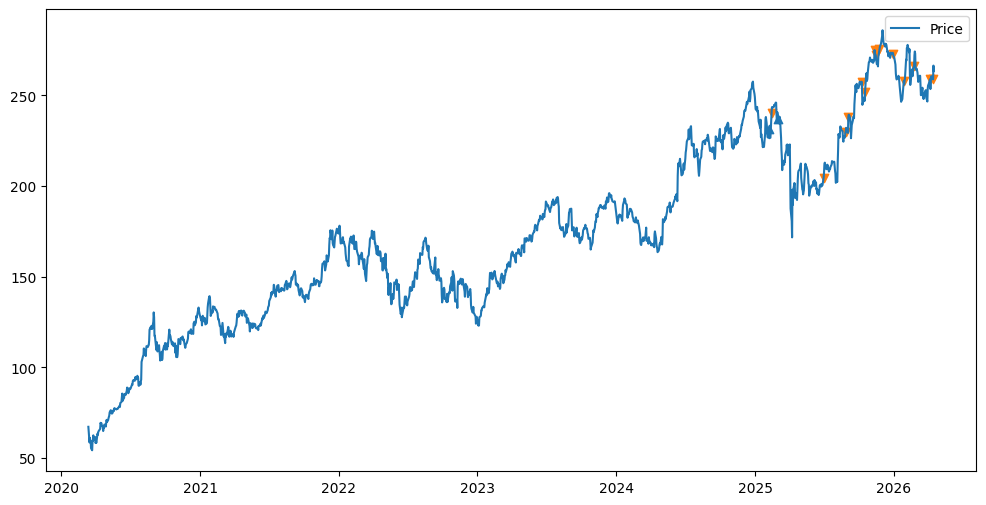

In [219]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

plt.figure(figsize=(12,6))

plt.plot(data['Close'], label='Price')

plt.scatter(buy.index, buy['Close'], marker='^')
plt.scatter(sell.index, sell['Close'], marker='v')

plt.legend()
plt.show()

In [220]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

fig = px.line(data, x=data.index, y='Close', title='Trading Signals')
fig.add_scatter(x=buy.index, y=buy['Close'], mode='markers', 
                marker=dict(symbol='triangle-up', size=10, color='green'), 
                name='STRONG BUY')
fig.add_scatter(x=sell.index, y=sell['Close'], mode='markers', 
                marker=dict(symbol='triangle-down', size=10, color='red'), 
                name='STRONG SELL')
fig.show()


In [221]:
latest = data.iloc[-1]

print("Price:", latest['Close'])
print("RSI Signal:", latest['Signal'])
print("ML Signal:", latest['ML_Signal'])
print("Final Signal:", latest['Final_Signal'])

Price: 263.3999938964844
RSI Signal: HOLD
ML Signal: SELL
Final Signal: WEAK SELL


In [222]:
#confidance score
confidence = 0

if latest['Signal'] == latest['ML_Signal']:
    confidence = 2
elif latest['ML_Signal'] != 'HOLD':
    confidence = 1
else:
    confidence = 0

print("Confidence:", confidence)

Confidence: 1


In [223]:
# Decision Sytem 
if latest['Final_Signal'] == 'STRONG BUY':
    print("ENTER TRADE")
elif latest['Final_Signal'] == 'STRONG SELL':
    print("EXIT / SHORT")
else:
    print("WAIT")

WAIT


In [224]:
#  Backtesting
#Variables
capital = 10000
position = 0 
buy_price = 0
stop_loss = 0.03
take_profit = 0.05
# Loop 
trades = []
for i in range(len(data)):
    signal = data['Final_Signal'].iloc[i]
    price = data['Close'].iloc[i]
    #Buy
    if signal == 'STRONG BUY' and position == 0:
        position = capital / price
        buy_price = price
        capital = 0
        trades.append(('Buy', price, data.index[i]))
    #Sell
    elif signal == 'STRONG SELL' and position != 0:
        capital = position * price
        position = 0
        trades.append(('SELL', price, data.index[i]))
    elif position != 0:
        if price < buy_price * (1 - stop_loss):
            capital = position * price
            position = 0
            trades.append(('STOP LOSS', price, data.index[i]))
        elif price > buy_price * (1 + take_profit):
            capital = position * price
            position = 0
            trades.append(('TAKE PROFIT', price, data.index[i]))

In [225]:
# calculating  value 
if position != 0:
    capital = position * data['Close'].iloc[-1]

print("Final Capital:", capital)

Final Capital: 9940.149126640614


In [226]:
profit = capital - 10000
print("Profit:",profit)

Profit: -59.85087335938624


In [227]:
# Buy pe
capital = capital * (1 - 0.001)

# Sell pe
capital = capital * (1 - 0.001)

In [228]:
print("Total Trades:", len(trades)//2)

Total Trades: 2


In [229]:
profits = []
wins = 0
total = 0

for i in range(0, len(trades)-1, 2):
    buy_price = trades[i][1]
    sell_price = trades[i+1][1]

    if sell_price > buy_price:
        wins += 1

    total += 1

print("Win Rate:", wins/total if total > 0 else 0)

Win Rate: 0.5


In [230]:
returns = (capital - 10000) / 10000
print("Return %:", returns * 100)

Return %: -0.7972123146353988


In [231]:
data.to_json("dashboard.json", orient="records")